In [1]:
!pip install -q pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 1.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "/kaggle/input/competitions/store-sales-time-series-forecasting/"

training_data = pd.read_csv(
    DATA_PATH + "train.csv",
    parse_dates=["date"]
)

test = pd.read_csv(
    DATA_PATH + "test.csv",
    parse_dates=["date"]
)

stores = pd.read_csv(DATA_PATH + "stores.csv")

oil = pd.read_csv(
    DATA_PATH + "oil.csv",
    parse_dates=["date"]
)

holidays = pd.read_csv(
    DATA_PATH + "holidays_events.csv",
    parse_dates=["date"]
)

In [3]:
grocery = training_data[training_data['family'] == 'GROCERY I'].copy()
grocery_daily = grocery.groupby('date')['sales'].sum()
grocery['year'] = grocery['date'].dt.year
grocery['month'] = grocery['date'].dt.month
grocery['day'] = grocery['date'].dt.day
grocery['dayofweek'] = grocery['date'].dt.dayofweek  # 0=Monday, 6=Sunday
grocery['is_weekend'] = (grocery['dayofweek'] >= 5).astype(int)  # 1 if weekend
grocery['day_of_year'] = grocery['date'].dt.dayofyear

Lag Features:
         date     sales  sales_lag_1  sales_lag_7  sales_lag_14
0  2013-01-01     700.0          NaN          NaN           NaN
1  2013-01-02  202020.0        700.0          NaN           NaN
2  2013-01-03  144878.0     202020.0          NaN           NaN
3  2013-01-04  135754.0     144878.0          NaN           NaN
4  2013-01-05  188356.0     135754.0          NaN           NaN
5  2013-01-06  207297.0     188356.0          NaN           NaN
6  2013-01-07  133189.0     207297.0          NaN           NaN
7  2013-01-08  133290.0     133189.0        700.0           NaN
8  2013-01-09  115871.0     133290.0     202020.0           NaN
9  2013-01-10   96200.0     115871.0     144878.0           NaN
10 2013-01-11  103280.0      96200.0     135754.0           NaN
11 2013-01-12  151025.0     103280.0     188356.0           NaN
12 2013-01-13  183099.0     151025.0     207297.0           NaN
13 2013-01-14  112128.0     183099.0     133189.0           NaN
14 2013-01-15  114578.0   

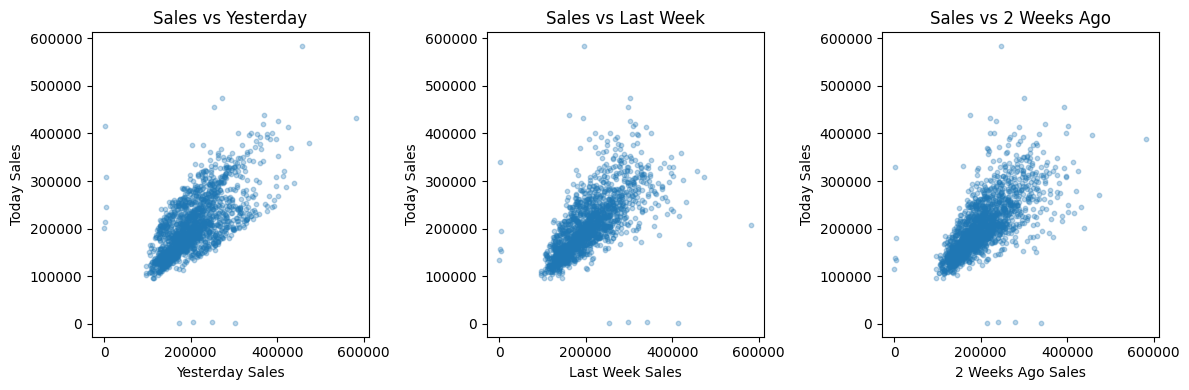

In [4]:

daily_sales = grocery.groupby('date')['sales'].sum().reset_index()
daily_sales = daily_sales.sort_values('date')

daily_sales['sales_lag_1'] = daily_sales['sales'].shift(1)   # 昨天
daily_sales['sales_lag_7'] = daily_sales['sales'].shift(7)   # 上周同一天
daily_sales['sales_lag_14'] = daily_sales['sales'].shift(14) # 两周前

print("Lag Features:")
print(daily_sales[['date', 'sales', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14']].head(20))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(daily_sales['sales_lag_1'], daily_sales['sales'], alpha=0.3, s=10)
plt.xlabel('Yesterday Sales')
plt.ylabel('Today Sales')
plt.title('Sales vs Yesterday')

plt.subplot(1, 3, 2)
plt.scatter(daily_sales['sales_lag_7'], daily_sales['sales'], alpha=0.3, s=10)
plt.xlabel('Last Week Sales')
plt.ylabel('Today Sales')
plt.title('Sales vs Last Week')

plt.subplot(1, 3, 3)
plt.scatter(daily_sales['sales_lag_14'], daily_sales['sales'], alpha=0.3, s=10)
plt.xlabel('2 Weeks Ago Sales')
plt.ylabel('Today Sales')
plt.title('Sales vs 2 Weeks Ago')

plt.tight_layout()
plt.show()

Rolling Features:
           date       sales  rolling_mean_7  rolling_mean_14  rolling_std_7
1664 2017-07-27  196079.180   233986.571714    236307.808786   37350.603551
1665 2017-07-28  233685.813   236287.837571    238000.313286   36660.945565
1666 2017-07-29  303657.532   241220.878714    239952.761214   43501.187924
1667 2017-07-30  328519.734   245624.884000    241340.988714   51072.644477
1668 2017-07-31  270215.666   249842.655571    243398.035214   51811.081290
1669 2017-08-01  301453.492   262766.580714    249792.987786   51786.378481
1670 2017-08-02  281631.338   273606.107857    254271.868071   45412.966452
1671 2017-08-03  227658.804   278117.482714    256052.027214   37265.461666
1672 2017-08-04  244474.234   279658.685714    257973.261643   35292.481642
1673 2017-08-05  292312.398   278037.952286    259629.415500   34251.861109
1674 2017-08-06  314408.414   276022.049429    260823.466714   31051.283082
1675 2017-08-07  244548.234   272355.273429    261098.964500   33286.2

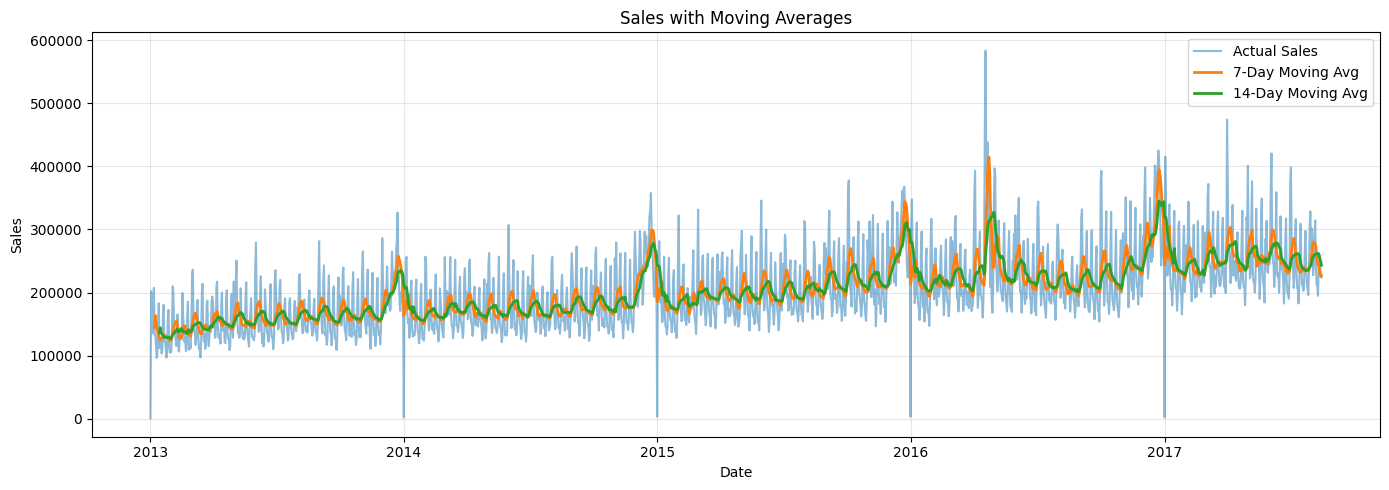

In [5]:
daily_sales['rolling_mean_7'] = daily_sales['sales'].rolling(window=7).mean()

daily_sales['rolling_mean_14'] = daily_sales['sales'].rolling(window=14).mean()

daily_sales['rolling_std_7'] = daily_sales['sales'].rolling(window=7).std()

print("Rolling Features:")
print(daily_sales[['date', 'sales', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7']].tail(20))


plt.figure(figsize=(14, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], label='Actual Sales', alpha=0.5)
plt.plot(daily_sales['date'], daily_sales['rolling_mean_7'], label='7-Day Moving Avg', linewidth=2)
plt.plot(daily_sales['date'], daily_sales['rolling_mean_14'], label='14-Day Moving Avg', linewidth=2)
plt.title('Sales with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

合并oil price后:
        date     sales  dcoilwtico
0 2013-01-01     700.0         NaN
1 2013-01-02  202020.0       93.14
2 2013-01-03  144878.0       92.97
3 2013-01-04  135754.0       93.12
4 2013-01-05  188356.0         NaN
5 2013-01-06  207297.0         NaN
6 2013-01-07  133189.0       93.20
7 2013-01-08  133290.0       93.21
8 2013-01-09  115871.0       93.08
9 2013-01-10   96200.0       93.81


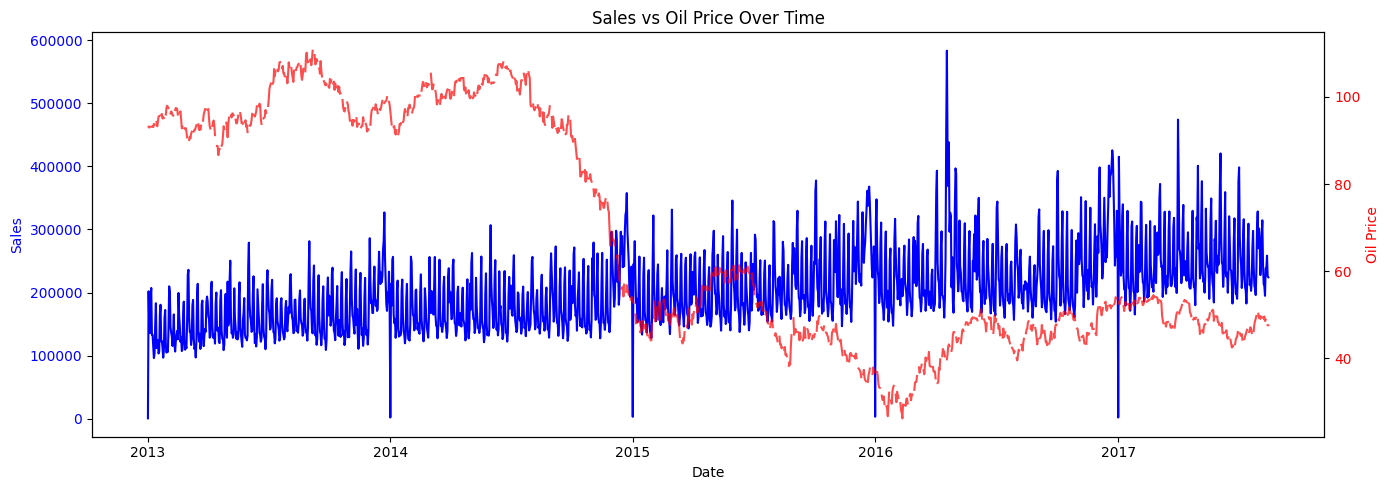

In [6]:
oil_clean = oil.copy()
oil_clean['dcoilwtico'] = oil_clean['dcoilwtico'].interpolate(method='linear')

daily_sales = daily_sales.merge(oil_clean, on='date', how='left')

print("合并oil price后:")
print(daily_sales[['date', 'sales', 'dcoilwtico']].head(10))

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(daily_sales['date'], daily_sales['sales'], color='blue', label='Sales')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(daily_sales['date'], daily_sales['dcoilwtico'], color='red', alpha=0.7, label='Oil Price')
ax2.set_ylabel('Oil Price', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Sales vs Oil Price Over Time')
plt.tight_layout()
plt.show()

In [7]:
correlation = daily_sales[['sales', 'dcoilwtico']].corr()
print(correlation)

               sales  dcoilwtico
sales       1.000000   -0.564923
dcoilwtico -0.564923    1.000000


In [8]:
# 删除有NaN的行
model_data = daily_sales.dropna().copy()

# 在创建feature_columns之前加：
if 'total_promotions' not in model_data.columns:
    model_data['total_promotions'] = 0  # 或者用平均值

# 选择要用的features
feature_columns = [
    'dcoilwtico',           # 油价
    'total_promotions',     # 促销数量
    'sales_lag_7',          # 上周销售
    'rolling_mean_7'        # 7天移动平均
]

# 提取时间特征
model_data['dayofweek'] = pd.to_datetime(model_data['date']).dt.dayofweek
model_data['is_weekend'] = (model_data['dayofweek'] >= 5).astype(int)

# 加入时间特征
feature_columns.extend(['dayofweek', 'is_weekend'])

print("用于建模的features:")
print(feature_columns)

# 准备X和y
X = model_data[feature_columns]
y = model_data['sales']

print("\nFeature数据preview:")
print(X.head())

用于建模的features:
['dcoilwtico', 'total_promotions', 'sales_lag_7', 'rolling_mean_7', 'dayofweek', 'is_weekend']

Feature数据preview:
    dcoilwtico  total_promotions  sales_lag_7  rolling_mean_7  dayofweek  \
14       93.26                 0     133290.0   125168.714286          1   
15       94.28                 0     115871.0   126369.428571          2   
16       95.49                 0      96200.0   127404.142857          3   
17       95.61                 0     103280.0   127933.000000          4   
20       95.85                 0     112128.0   131072.142857          0   

    is_weekend  
14           0  
15           0  
16           0  
17           0  
20           0  


In [9]:
# 最后15天作为测试
train_size = len(model_data) - 15

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print(f"训练集: {len(X_train)} 天")
print(f"测试集: {len(X_test)} 天")

训练集: 1178 天
测试集: 15 天


In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

print("训练SARIMA（无features）...")

# 不加features的SARIMA
sarima_basic = SARIMAX(y_train,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 7))

sarima_basic_fit = sarima_basic.fit(disp=False)
sarima_basic_pred = sarima_basic_fit.forecast(steps=len(y_test))

print("✓ SARIMA基础版训练完成")

训练SARIMA（无features）...
✓ SARIMA基础版训练完成


In [11]:
print("训练SARIMA（加features）...")

# 加features的SARIMA - 用exog参数！
sarima_with_features = SARIMAX(y_train,
                               exog=X_train,  # 这里加features！
                               order=(1, 1, 1),
                               seasonal_order=(1, 1, 1, 7))

sarima_features_fit = sarima_with_features.fit(disp=False)

# 预测时也要提供features！
sarima_features_pred = sarima_features_fit.forecast(steps=len(y_test), exog=X_test)

print("✓ SARIMA + Features训练完成")

训练SARIMA（加features）...
✓ SARIMA + Features训练完成


In [12]:
# Baseline: 用上周同一天的值
def last_week_forecast(train_data, test_size):
    predictions = []
    for i in range(test_size):
        pred = train_data.iloc[-(7-i%7)]  # 上周同一天
        predictions.append(pred)
    return np.array(predictions)

baseline_pred = last_week_forecast(y_train, len(y_test))

print("✓ Baseline完成")

✓ Baseline完成


In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

actual = y_test.values

# 计算每个模型的指标
def calc_metrics(actual, pred, name):
    mse = mean_squared_error(actual, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, pred)
    return {'Model': name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae}

results = []
results.append(calc_metrics(actual, baseline_pred, "Baseline (Last Week)"))
results.append(calc_metrics(actual, sarima_basic_pred.values, "SARIMA (No Features)"))
results.append(calc_metrics(actual, sarima_features_pred.values, "SARIMA + Features"))

results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("模型对比 - Out of Sample Performance")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# 找出最好的模型
best_model = results_df.loc[results_df['RMSE'].idxmin()]
print(f"\n🏆 最佳模型: {best_model['Model']}")
print(f"   RMSE: {best_model['RMSE']:.2f}")

# 计算improvement
baseline_rmse = results_df[results_df['Model'] == 'Baseline (Last Week)']['RMSE'].values[0]
best_rmse = best_model['RMSE']
improvement = (baseline_rmse - best_rmse) / baseline_rmse * 100

print(f"   比Baseline提升: {improvement:.1f}%")


模型对比 - Out of Sample Performance
               Model          MSE         RMSE          MAE
Baseline (Last Week) 1.164109e+09 34119.040392 25338.170600
SARIMA (No Features) 1.139703e+09 33759.486774 24020.183574
   SARIMA + Features 8.547250e+08 29235.680850 22865.127640

🏆 最佳模型: SARIMA + Features
   RMSE: 29235.68
   比Baseline提升: 14.3%


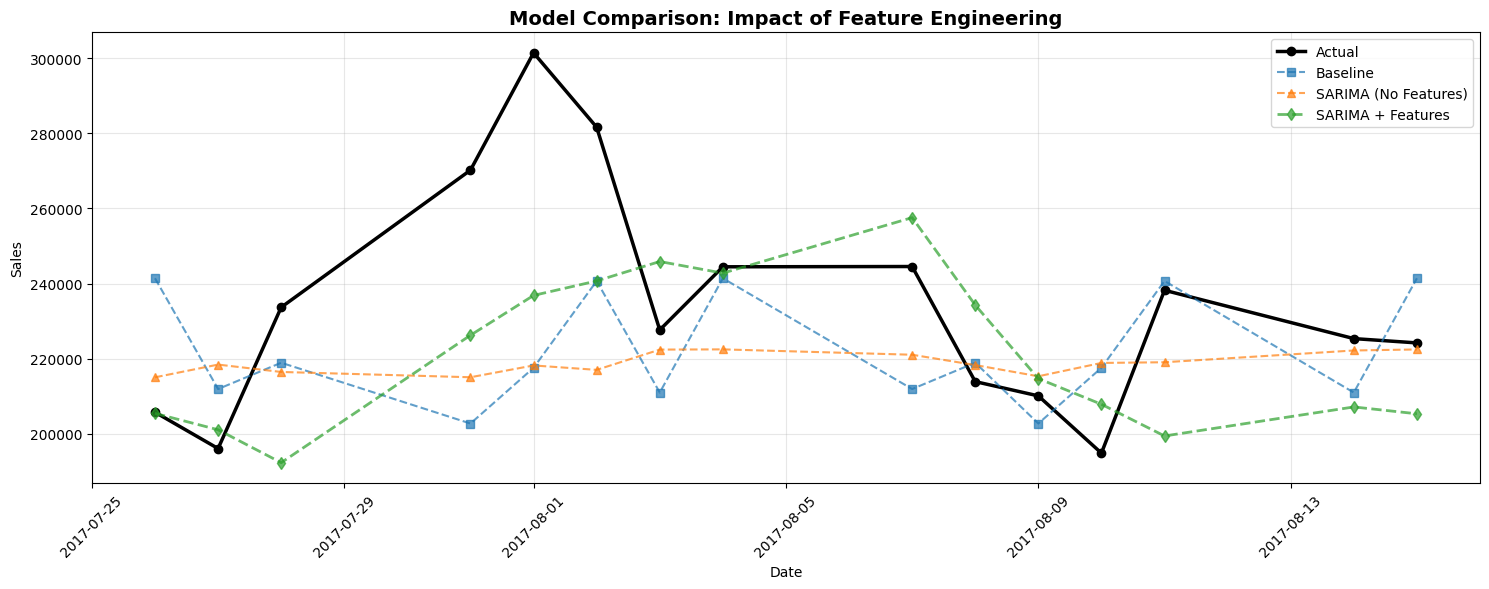

In [14]:
test_dates = model_data['date'].iloc[train_size:].values

plt.figure(figsize=(15, 6))

# 真实值
plt.plot(test_dates, actual, label='Actual', color='black', linewidth=2.5, marker='o', markersize=6)

# 3个模型
plt.plot(test_dates, baseline_pred, label='Baseline', linestyle='--', marker='s', alpha=0.7)
plt.plot(test_dates, sarima_basic_pred.values, label='SARIMA (No Features)', linestyle='--', marker='^', alpha=0.7)
plt.plot(test_dates, sarima_features_pred.values, label='SARIMA + Features', linestyle='--', marker='d', alpha=0.7, linewidth=2)

plt.title('Model Comparison: Impact of Feature Engineering', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


SARIMA + Features 参数:
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
dcoilwtico        -799.7756    505.349     -1.583      0.114   -1790.241     190.690
total_promotions  -4.97e-11    1.2e+05  -4.15e-16      1.000   -2.35e+05    2.35e+05
sales_lag_7         -0.0123      0.041     -0.305      0.761      -0.092       0.067
rolling_mean_7       1.0616      0.073     14.498      0.000       0.918       1.205
dayofweek        -5608.9845   1295.582     -4.329      0.000   -8148.279   -3069.690
is_weekend                0    1.2e+05          0      1.000   -2.35e+05    2.35e+05
ar.L1                0.3885      0.052      7.426      0.000       0.286       0.491
ma.L1               -0.9759      0.025    -38.597      0.000      -1.025      -0.926
ar.S.L7             -0.0545      0.066     -0.820      0.412      -0.185       0.076
ma.S.L7             -0.9660      0.028    

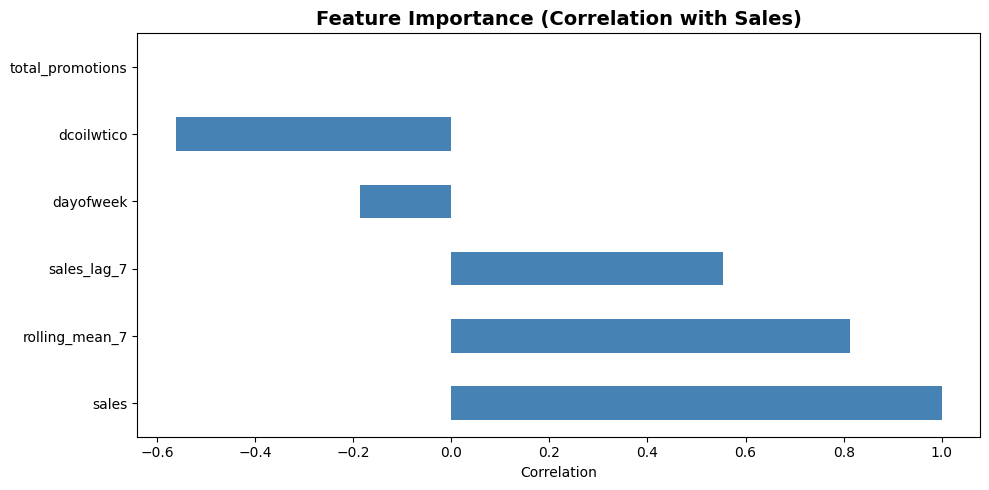

In [15]:
# 看模型的coefficients
print("\nSARIMA + Features 参数:")
print(sarima_features_fit.summary().tables[1])

# 或者简单点，看feature的correlation
print("\nFeatures与Sales的相关性:")
correlations = model_data[feature_columns + ['sales']].corr()['sales'].sort_values(ascending=False)
print(correlations)

# 画个bar chart
plt.figure(figsize=(10, 5))
correlations[:-1].plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Correlation with Sales)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

# New Section

In [16]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

FEATURE_COLUMNS = ['dcoilwtico', 'total_promotions', 'sales_lag_7', 'rolling_mean_7', 'dayofweek', 'is_weekend']

In [17]:
def build_family_daily(family_name, training_data, oil_clean):
    # 准备数据
    
    fam = training_data[training_data['family'] == family_name].copy()
    daily = fam.groupby('date')['sales'].sum().reset_index()
    daily = daily.sort_values('date').reset_index(drop=True)
    
    # Features - yesterday + last week + last last week
    daily['sales_lag_1'] = daily['sales'].shift(1)   # 昨天
    daily['sales_lag_7'] = daily['sales'].shift(7)   # 上周同一天
    daily['sales_lag_14'] = daily['sales'].shift(14) # 两周前
    
    # Features - rolling average
    daily['rolling_mean_7'] = daily['sales'].rolling(window=7).mean()
    daily['rolling_mean_14'] = daily['sales'].rolling(window=14).mean()
    daily['rolling_std_7'] = daily['sales'].rolling(window=7).std()
    
    # Oil price
    daily = daily.merge(oil_clean, on='date', how='left')

    # Promotions (from training data)
    promo = fam.groupby('date')['onpromotion'].sum().reset_index()
    promo.columns = ['date', 'total_promotions']
    daily = daily.merge(promo, on='date', how='left')
    daily['total_promotions'] = daily['total_promotions'].fillna(0)

    # Time features
    daily['dayofweek'] = pd.to_datetime(daily['date']).dt.dayofweek
    daily['is_weekend'] = (daily['dayofweek'] >= 5).astype(int)
    
    daily = daily.dropna().reset_index(drop=True)
    return daily


def fit_sarima(y_train, X_train):
    # 训练模型
    
    if y_train.sum() == 0:
        return None
    model = auto_arima(
        y_train,
        exogenous=X_train,
        seasonal=True, m=7,          # weekly seasonality
        stepwise=True,               # fast stepwise search
        information_criterion='aic',
        suppress_warnings=True,
        error_action='ignore',
    )
    return model


def build_test_exog(family_name, training_data, test, oil_clean):

    fam_train = training_data[training_data['family'] == family_name].copy()
    daily_train = fam_train.groupby('date')['sales'].sum().reset_index()
    daily_train = daily_train.sort_values('date').reset_index(drop=True)

    test_fam   = test[test['family'] == family_name].copy()
    test_dates = sorted(test_fam['date'].unique())

    # Combine last 14 training days + test dates (test sales unknown = NaN)
    last_14  = daily_train.tail(14)[['date', 'sales']].copy()
    test_df  = pd.DataFrame({'date': test_dates, 'sales': np.nan})
    combined = pd.concat([last_14, test_df], ignore_index=True)
    combined = combined.sort_values('date').reset_index(drop=True)

    combined['sales_lag_7'] = combined['sales'].shift(7)

    # Extract test rows only
    test_exog = combined[combined['date'].isin(test_dates)].copy()
    # Forward-fill lag_7 for test days 8-16 where actuals are unavailable
    test_exog['sales_lag_7'] = test_exog['sales_lag_7'].ffill()
    # rolling_mean_7: rolling window would include unknown test actuals,
    # so use the last 7 training days' mean as the best available approximation
    test_exog['rolling_mean_7'] = daily_train['sales'].tail(7).mean()
    # Oil price
    test_exog = test_exog.merge(oil_clean, on='date', how='left')
    test_exog['dcoilwtico'] = test_exog['dcoilwtico'].ffill()

    # Promotions from test.csv
    promo = test_fam.groupby('date')['onpromotion'].sum().reset_index()
    promo.columns = ['date', 'total_promotions']
    test_exog = test_exog.merge(promo, on='date', how='left')
    test_exog['total_promotions'] = test_exog['total_promotions'].fillna(0)

    # Time features
    test_exog['dayofweek'] = pd.to_datetime(test_exog['date']).dt.dayofweek
    test_exog['is_weekend'] = (test_exog['dayofweek'] >= 5).astype(int)

    return test_exog[['date'] + FEATURE_COLUMNS].reset_index(drop=True)

In [18]:
n_test_days = test['date'].nunique()
families = sorted(test['family'].unique())

family_forecasts = {}
failed_families = []

In [19]:
for i, family in enumerate(families):
    # prepare data
    daily = build_family_daily(family, training_data, oil_clean)
    X_all = daily[FEATURE_COLUMNS]
    y_all = daily['sales']
    
    # fit and train model
    fit = fit_sarima(y_all, X_all)
    
    if fit is None:
        # Fallback: repeat last week
        tail = y_all.tail(7).values
        fallback = np.tile(tail, 3)[:n_test_days]
        family_forecasts[family] = fallback
        failed_families.append(family)
        print('FALLBACK (zero sales or fit error)')
        continue
    
    # Build test exog features
    test_exog_df = build_test_exog(family, training_data, test, oil_clean)
    X_test_fc    = test_exog_df[FEATURE_COLUMNS]
    
    pred = fit.predict(n_periods = 16, exogenous = X_test_fc)
    family_forecasts[family] = np.maximum(pred, 0)  # clip negatives
    print('Forecast completed for ', family, ". Progress: ", str(i+1), "/33")
    
print(f'\nCompleted: {len(families) - len(failed_families)}/{len(families)} Auto-ARIMA fits succeeded')
if failed_families:
    print(f'Fallback used for: {failed_families}')

Forecast completed for  AUTOMOTIVE . Progress:  1 /33
Forecast completed for  BABY CARE . Progress:  2 /33
Forecast completed for  BEAUTY . Progress:  3 /33
Forecast completed for  BEVERAGES . Progress:  4 /33
Forecast completed for  BOOKS . Progress:  5 /33
Forecast completed for  BREAD/BAKERY . Progress:  6 /33
Forecast completed for  CELEBRATION . Progress:  7 /33
Forecast completed for  CLEANING . Progress:  8 /33
Forecast completed for  DAIRY . Progress:  9 /33
Forecast completed for  DELI . Progress:  10 /33
Forecast completed for  EGGS . Progress:  11 /33
Forecast completed for  FROZEN FOODS . Progress:  12 /33
Forecast completed for  GROCERY I . Progress:  13 /33
Forecast completed for  GROCERY II . Progress:  14 /33
Forecast completed for  HARDWARE . Progress:  15 /33
Forecast completed for  HOME AND KITCHEN I . Progress:  16 /33
Forecast completed for  HOME AND KITCHEN II . Progress:  17 /33
Forecast completed for  HOME APPLIANCES . Progress:  18 /33
Forecast completed for  H

In [20]:
# ── Compute store-level shares and build submission.csv ──────────────────────

# Historical share of each store within each family (full training period)
store_sales   = training_data.groupby(['family', 'store_nbr'])['sales'].sum().reset_index()
family_totals = store_sales.groupby('family')['sales'].transform('sum')
store_sales['share'] = store_sales['sales'] / family_totals.replace(0, 1)

print(f'Store shares computed: {len(store_sales)} (family, store) pairs')

# Build a long-form (family, date, family_forecast) DataFrame
test_dates_sorted = sorted(test['date'].unique())

fc_records = []
for family, forecasts in family_forecasts.items():
    for date, pred in zip(test_dates_sorted, forecasts):
        fc_records.append({'family': family, 'date': date, 'family_forecast': float(pred)})

fc_df = pd.DataFrame(fc_records)

# Join test.csv (authoritative list of ids) with forecasts and store shares
sub = test[['id', 'date', 'store_nbr', 'family']].copy()
sub = sub.merge(fc_df, on=['family', 'date'], how='left')
sub = sub.merge(store_sales[['family', 'store_nbr', 'share']],
                on=['family', 'store_nbr'], how='left')

sub['sales'] = (sub['family_forecast'] * sub['share']).clip(lower=0).fillna(0)

submission = sub[['id', 'sales']].sort_values('id').reset_index(drop=True)

# Sanity checks
print(f'\nSubmission shape : {submission.shape}  (expected (28512, 2))')
print(f'Missing sales    : {submission["sales"].isna().sum()}')
print(f'Negative sales   : {(submission["sales"] < 0).sum()}')
print(f'Total forecast   : {submission["sales"].sum():,.0f}')
print('\nSample rows:')
print(submission.head(10))

submission.to_csv('submission.csv', index=False)
print('\nSaved: submission.csv')


Store shares computed: 1782 (family, store) pairs

Submission shape : (28512, 2)  (expected (28512, 2))
Missing sales    : 0
Negative sales   : 0
Total forecast   : 12,579,281

Sample rows:
        id        sales
0  3000888     3.384903
1  3000889     0.000000
2  3000890     3.768459
3  3000891  2103.868708
4  3000892     0.000510
5  3000893   381.408886
6  3000894    13.528328
7  3000895   701.987972
8  3000896   734.041287
9  3000897   124.692115

Saved: submission.csv


In [21]:
print("Submission shape:", submission.shape)
print("Expected shape:", (len(test), 2))
print("Missing predictions:", submission["sales"].isna().sum())
print("Negative predictions:", (submission["sales"] < 0).sum())
print("Duplicate IDs:", submission["id"].duplicated().sum())

assert len(submission) == len(test)
assert submission["id"].nunique() == test["id"].nunique()
assert submission["sales"].notna().all()
assert (submission["sales"] >= 0).all()

print("✓ Submission validation passed")
submission.head()

Submission shape: (28512, 2)
Expected shape: (28512, 2)
Missing predictions: 0
Negative predictions: 0
Duplicate IDs: 0
✓ Submission validation passed


,id,sales
0,3000888,3.384903
1,3000889,0.000000
2,3000890,3.768459
3,3000891,2103.868708
4,3000892,0.000510


In [22]:
submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

print("submission.csv saved")

submission.csv saved


In [23]:
import os
print(os.listdir("/kaggle/working"))

['__notebook__.ipynb', 'submission.csv']
